[                       0%                       ]

Processing Singapore STI...


[*********************100%***********************]  3 of 3 completed


Successfully generated Gavekal_Singapore_STI.png


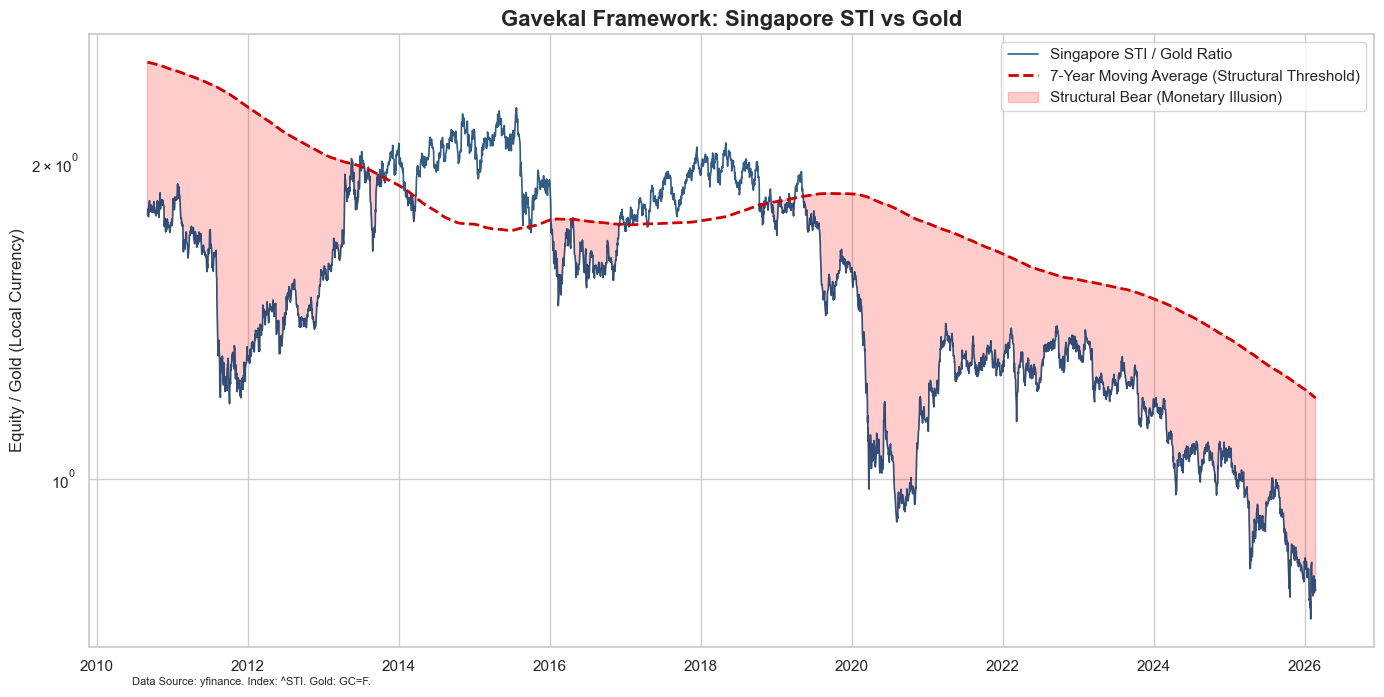

Processing Hong Kong HSI...


[*********************100%***********************]  3 of 3 completed


Successfully generated Gavekal_Hong_Kong_HSI.png


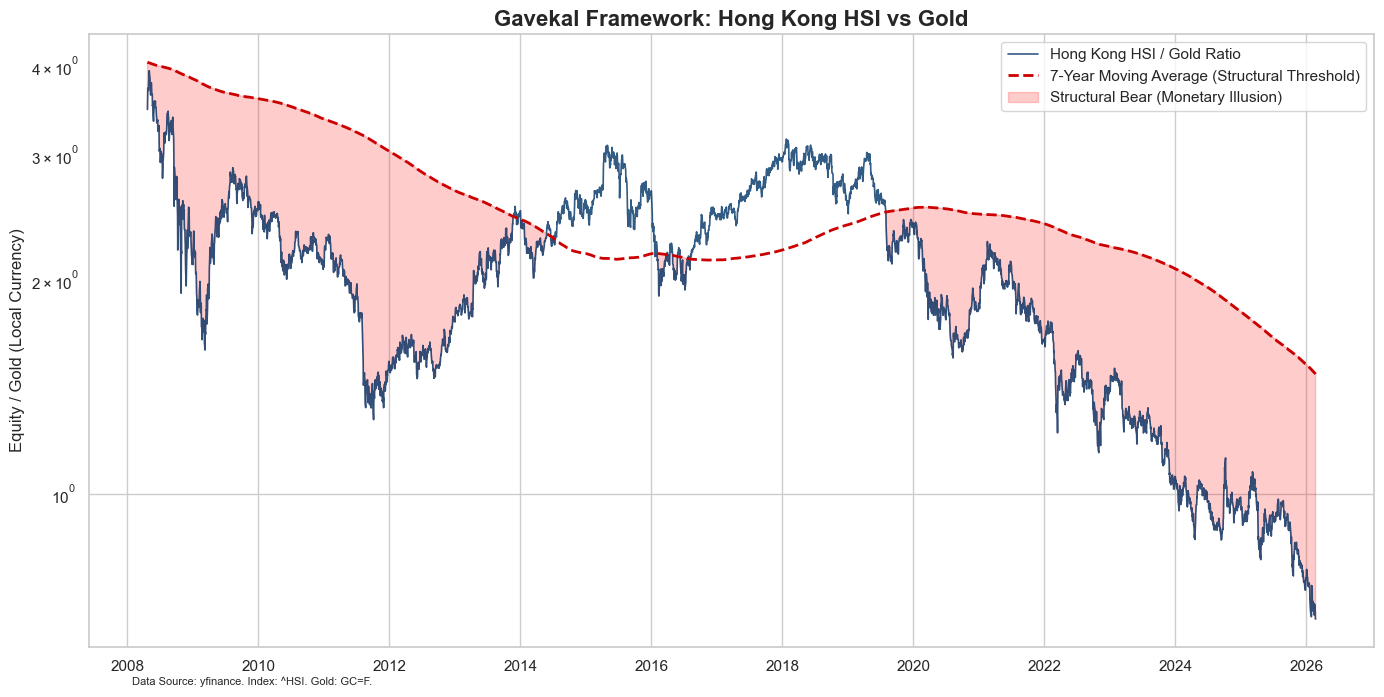

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup professional styling
sns.set_theme(style="whitegrid")

def fetch_gavekal_data(index_ticker, fx_ticker, gold_ticker, start_date):
    """
    Robust data fetcher that handles MultiIndex columns and missing Adj Close data.
    """
    tickers = [index_ticker, fx_ticker, gold_ticker]
    raw_data = yf.download(tickers, start=start_date, interval="1d")
    
    processed_df = pd.DataFrame(index=raw_data.index)
    
    for t in tickers:
        # Try to get Adjusted Close first (for dividends), fallback to Close
        if ('Adj Close', t) in raw_data.columns:
            processed_df[t] = raw_data[('Adj Close', t)]
        else:
            processed_df[t] = raw_data[('Close', t)]
            
    # Forward fill gaps (common in international FX/Index data alignment)
    return processed_df.ffill().dropna()

def generate_gavekal_chart(market_name, index_ticker, fx_ticker, gold_ticker='GC=F'):
    print(f"Processing {market_name}...")
    
    try:
        # 1. Retrieval
        df = fetch_gavekal_data(index_ticker, fx_ticker, gold_ticker, "1990-01-01")
        
        # 2. Calculations
        # Local Gold = Gold Price (USD) * FX Rate (Local/USD)
        df['Gold_Local'] = df[gold_ticker] * df[fx_ticker]
        
        # Ratio = Equity Index / Local Gold
        df['Ratio'] = df[index_ticker] / df['Gold_Local']
        
        # 7-Year Moving Average (252 days * 7 = 1764)
        df['7Y_MA'] = df['Ratio'].rolling(window=1764).mean()
        
        plot_df = df.dropna(subset=['7Y_MA'])
        
        # 3. Visualization
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Main Ratio Line
        ax.plot(plot_df.index, plot_df['Ratio'], label=f'{market_name} / Gold Ratio', 
                color='#003366', lw=1.2, alpha=0.8)
        
        # 7-Year Moving Average
        ax.plot(plot_df.index, plot_df['7Y_MA'], label='7-Year Moving Average (Structural Threshold)', 
                color='#CC0000', linestyle='--', lw=2)
        
        # Shading: The "Monetary Illusion" / Structural Bear Zone
        ax.fill_between(plot_df.index, plot_df['Ratio'], plot_df['7Y_MA'],
                        where=(plot_df['Ratio'] < plot_df['7Y_MA']),
                        color='red', alpha=0.2, label='Structural Bear (Monetary Illusion)')
        
        # Styling
        ax.set_title(f"Gavekal Framework: {market_name} vs Gold", fontsize=16, fontweight='bold')
        ax.set_ylabel("Equity / Gold (Local Currency)", fontsize=12)
        ax.set_yscale('log') # Log scale is often used in Gavekal charts for long-term ratios
        ax.legend(loc='best')
        
        plt.figtext(0.1, 0.01, f"Data Source: yfinance. Index: {index_ticker}. Gold: {gold_ticker}.", fontsize=8)
        plt.tight_layout()
        
        filename = f"Gavekal_{market_name.replace(' ', '_')}.png"
        plt.savefig(filename, dpi=300)
        print(f"Successfully generated {filename}")
        plt.show()
        
    except Exception as e:
        print(f"Error analyzing {market_name}: {e}")

if __name__ == "__main__":
    # Singapore Analysis
    generate_gavekal_chart("Singapore STI", "^STI", "USDSGD=X")
    
    # Hong Kong Analysis
    generate_gavekal_chart("Hong Kong HSI", "^HSI", "USDHKD=X")

Generating Gavekal Analysis for United States (S&P 500)...


[*********************100%***********************]  2 of 2 completed


Successfully generated Gavekal_US_S&P500.png


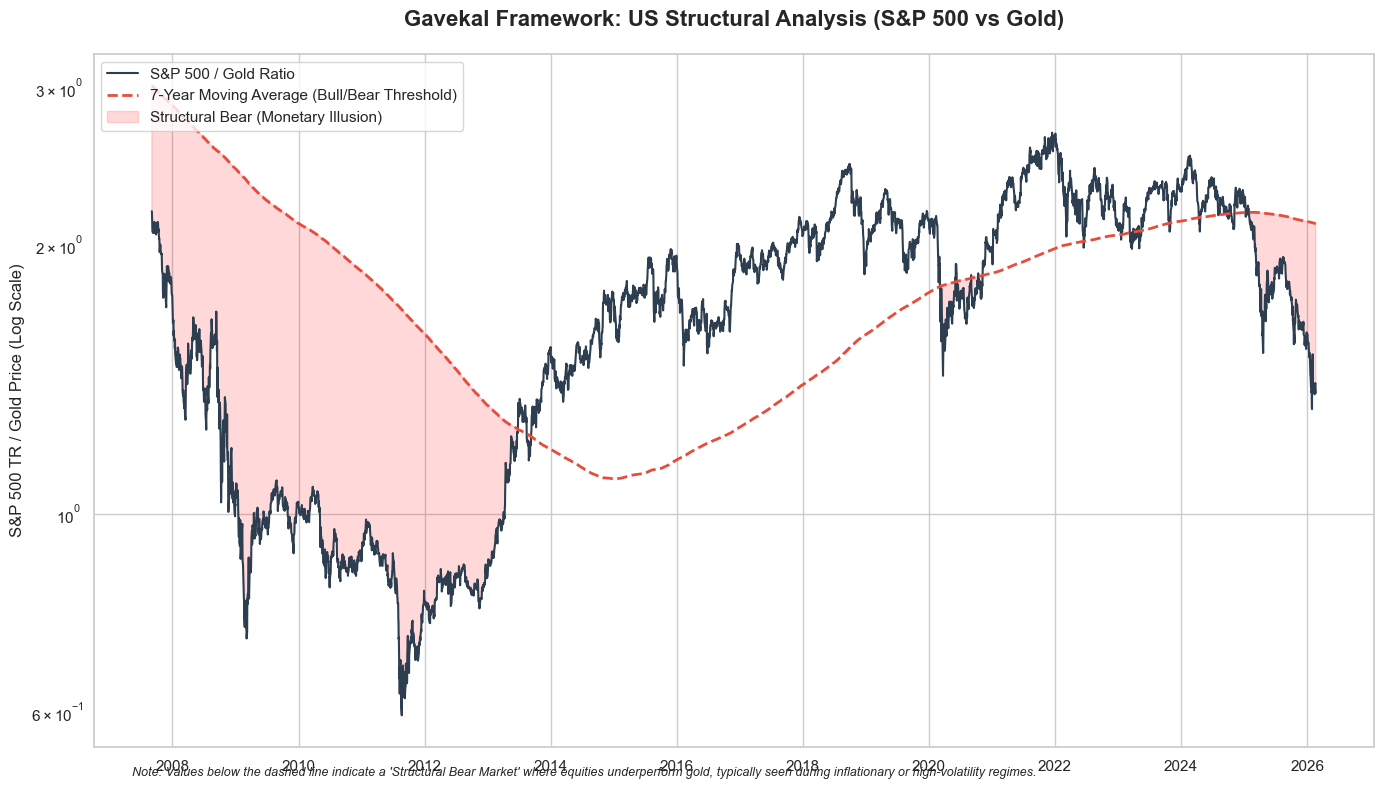

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup professional styling
sns.set_theme(style="whitegrid")

def fetch_us_gavekal_data(start_date="1990-01-01"):
    """
    Retrieves S&P 500 and Gold data, handling MultiIndex and calculating the ratio.
    """
    tickers = ["^GSPC", "GC=F"]
    # Download data
    raw_data = yf.download(tickers, start=start_date, interval="1d")
    
    df = pd.DataFrame(index=raw_data.index)
    
    # Navigation of yfinance MultiIndex for US Tickers
    # Use Adj Close for S&P 500 to capture Total Return approximation
    for t in tickers:
        if ('Adj Close', t) in raw_data.columns:
            df[t] = raw_data[('Adj Close', t)]
        else:
            df[t] = raw_data[('Close', t)]
            
    return df.ffill().dropna()

def plot_us_gavekal_analysis():
    print("Generating Gavekal Analysis for United States (S&P 500)...")
    
    try:
        # 1. Data Prep
        df = fetch_us_gavekal_data()
        
        # 2. Ratio Calculation
        # In the US, Local Gold = USD Gold Price
        df['Ratio'] = df['^GSPC'] / df['GC=F']
        
        # 3. 7-Year Moving Average (1764 trading days)
        df['7Y_MA'] = df['Ratio'].rolling(window=1764).mean()
        
        plot_df = df.dropna(subset=['7Y_MA'])
        
        # 4. Visualization
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Plot Ratio
        ax.plot(plot_df.index, plot_df['Ratio'], label='S&P 500 / Gold Ratio', 
                color='#2c3e50', lw=1.5)
        
        # Plot 7Y Moving Average
        ax.plot(plot_df.index, plot_df['7Y_MA'], label='7-Year Moving Average (Bull/Bear Threshold)', 
                color='#e74c3c', linestyle='--', lw=2)
        
        # Shading: Structural Bear / Monetary Illusion
        ax.fill_between(plot_df.index, plot_df['Ratio'], plot_df['7Y_MA'],
                        where=(plot_df['Ratio'] < plot_df['7Y_MA']),
                        color='red', alpha=0.15, label='Structural Bear (Monetary Illusion)')
        
        # Logistics & Styling
        ax.set_yscale('log') # Essential for long-term US historical analysis
        ax.set_title("Gavekal Framework: US Structural Analysis (S&P 500 vs Gold)", 
                     fontsize=16, fontweight='bold', pad=20)
        ax.set_ylabel("S&P 500 TR / Gold Price (Log Scale)", fontsize=12)
        ax.legend(loc='upper left', frameon=True)
        
        # Annotations for historical context (e.g., Dotcom, GFC)
        plt.figtext(0.1, 0.02, 
                    "Note: Values below the dashed line indicate a 'Structural Bear Market' where "
                    "equities underperform gold, typically seen during inflationary or high-volatility regimes.", 
                    fontsize=9, style='italic')

        plt.tight_layout()
        plt.savefig("Gavekal_US_S&P500.png", dpi=300)
        print("Successfully generated Gavekal_US_S&P500.png")
        plt.show()

    except Exception as e:
        print(f"Error during US analysis: {e}")

if __name__ == "__main__":
    plot_us_gavekal_analysis()